# 05. Business Recommendation

This notebook consolidates the results from the previous notebooks into final business recommendations.

Workflow:

1. `01_raw_data_audit.ipynb`: raw data audit and processed layer creation
2. `02_event_funnel_analysis.ipynb`: user-level funnel analysis
3. `03_item_category_analysis.ipynb`: item/category opportunity analysis
4. `04_ab_test_design_simulation.ipynb`: A/B test design, sample size, and business impact simulation

Goal: translate analytical findings into practical business actions.

In [1]:
# ============================================================
# 0. Library Setting
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

print("pandas:", pd.__version__)
print("numpy:", np.__version__)

pandas: 2.2.3
numpy: 2.1.3


In [2]:
# ============================================================
# 1. Project Path Setting
# ============================================================

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
CHART_DIR = OUTPUT_DIR / "charts"
TABLE_DIR = OUTPUT_DIR / "tables"

for path in [PROCESSED_DIR, OUTPUT_DIR, CHART_DIR, TABLE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("TABLE_DIR:", TABLE_DIR)

PROJECT_ROOT: c:\Users\USER\Desktop\ecommerce_ab_test_project
PROCESSED_DIR: c:\Users\USER\Desktop\ecommerce_ab_test_project\data\processed
TABLE_DIR: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables


In [3]:
# ============================================================
# 2. Utility Functions
# ============================================================

def save_table(df: pd.DataFrame, filename: str, index: bool = False) -> Path:
    save_path = TABLE_DIR / filename
    df.to_csv(save_path, index=index, encoding="utf-8-sig")
    print(f"saved: {save_path}")
    return save_path


def save_chart(filename: str) -> Path:
    save_path = CHART_DIR / filename
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"saved: {save_path}")
    return save_path


def read_table(table_name: str, required: bool = True) -> pd.DataFrame:
    path = TABLE_DIR / table_name
    if path.exists():
        print(f"loaded: {path}")
        return pd.read_csv(path)
    if required:
        raise FileNotFoundError(f"Required table not found: {path}")
    print(f"optional table not found: {path}")
    return pd.DataFrame()

## 1. Load Key Result Tables

This notebook uses summary tables created from notebooks 02, 03, and 04.

In [4]:
# ============================================================
# 3. Load Key Analysis Results
# ============================================================

conversion_summary = read_table("02_user_level_conversion_summary.csv")
funnel_insight_summary = read_table("02_funnel_insight_summary.csv")

business_insight_summary = read_table("03_business_insight_summary.csv")
category_opportunity_summary = read_table("03_category_opportunity_summary.csv", required=False)
item_opportunity_summary = read_table("03_item_opportunity_summary.csv", required=False)

optimization_candidate_categories = read_table("03_abtest_optimization_candidate_categories.csv", required=False)
expansion_candidate_categories = read_table("03_abtest_expansion_candidate_categories.csv", required=False)
star_categories = read_table("03_star_categories.csv", required=False)

baseline_conversion_summary = read_table("04_baseline_conversion_summary.csv")
sample_size_scenarios = read_table("04_sample_size_scenarios_view_to_cart.csv")
business_impact_scenarios = read_table("04_business_impact_scenarios.csv")
final_abtest_insight_summary = read_table("04_final_abtest_insight_summary.csv")

display(conversion_summary)
display(business_insight_summary)
display(sample_size_scenarios)

loaded: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\02_user_level_conversion_summary.csv
loaded: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\02_funnel_insight_summary.csv
loaded: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\03_business_insight_summary.csv
loaded: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\03_category_opportunity_summary.csv
loaded: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\03_item_opportunity_summary.csv
loaded: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\03_abtest_optimization_candidate_categories.csv
loaded: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\03_abtest_expansion_candidate_categories.csv
loaded: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\03_star_categories.csv
loaded: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\04_baseline_conversion_summary.csv
loaded: c:\Users\USER\Desktop\ecommerce_ab_

,conversion_step,numerator,denominator,conversion_rate,conversion_rate_pct
0,View → Add to Cart,37722,1404179,0.026864,2.686410
1,Add to Cart → Purchase,11719,37722,0.310668,31.066751
2,View → Purchase,11719,1404179,0.008346,0.834580


,insight_area,finding,business_action
0,Top purchase category,Category 959 generated the highest number of p...,Maintain exposure and use as a benchmark for h...
1,Top traffic category,Category 1483 generated the highest number of ...,Monitor whether high traffic is efficiently co...
2,Optimization opportunity,"Category 1483 has high traffic (40,486 view us...","Prioritize A/B tests on product detail UX, CTA..."
3,Expansion opportunity,Category 57 shows strong purchase conversion (...,Consider increasing exposure through recommend...
4,A/B Test primary metric,The item/category analysis supports View → Add...,Use View → Add to Cart conversion as the prima...


,primary_metric,baseline_rate,baseline_rate_pct,relative_uplift,relative_uplift_pct,treatment_rate,treatment_rate_pct,absolute_lift,absolute_lift_pct_point,required_sample_size_per_group,required_total_sample_size,alpha,power
0,View → Add to Cart,0.026864,2.686410,0.050000,5.000000,0.028207,2.820730,0.001343,0.134320,232948,465896,0.050000,0.800000
1,View → Add to Cart,0.026864,2.686410,0.100000,10.000000,0.029551,2.955051,0.002686,0.268641,59592,119184,0.050000,0.800000
2,View → Add to Cart,0.026864,2.686410,0.150000,15.000000,0.030894,3.089371,0.004030,0.402961,27080,54160,0.050000,0.800000
3,View → Add to Cart,0.026864,2.686410,0.200000,20.000000,0.032237,3.223692,0.005373,0.537282,15563,31126,0.050000,0.800000
4,View → Add to Cart,0.026864,2.686410,0.300000,30.000000,0.034923,3.492333,0.008059,0.805923,7206,14412,0.050000,0.800000


## 2. Executive Summary

Key message:

> Conversion improvement should prioritize high-traffic, low-conversion items and categories rather than changing the whole platform at once.

In [5]:
# ============================================================
# 4. Executive Summary
# ============================================================

view_to_cart = conversion_summary.loc[
    conversion_summary["conversion_step"] == "View → Add to Cart",
    "conversion_rate"
].iloc[0]

cart_to_purchase = conversion_summary.loc[
    conversion_summary["conversion_step"] == "Add to Cart → Purchase",
    "conversion_rate"
].iloc[0]

view_to_purchase = conversion_summary.loc[
    conversion_summary["conversion_step"] == "View → Purchase",
    "conversion_rate"
].iloc[0]

uplift_10 = sample_size_scenarios.loc[
    sample_size_scenarios["relative_uplift"] == 0.10
].iloc[0]

impact_100k_10 = business_impact_scenarios.loc[
    (business_impact_scenarios["relative_uplift"] == 0.10)
    & (business_impact_scenarios["target_exposures"] == 100000)
].iloc[0]

executive_summary = pd.DataFrame([
    {
        "section": "Core finding",
        "message": (
            f"The largest funnel bottleneck occurs before cart entry. "
            f"View → Add to Cart conversion is {view_to_cart * 100:.2f}%."
        ),
        "business_implication": (
            "Product detail pages, recommendation modules, CTA copy, and cart-entry incentives "
            "should be prioritized over broad checkout-only optimization."
        ),
    },
    {
        "section": "Business opportunity",
        "message": "High-traffic low-conversion items and categories were identified as primary optimization targets.",
        "business_implication": "These areas already have user attention, so conversion improvements can create impact without additional acquisition cost.",
    },
    {
        "section": "Experiment strategy",
        "message": "The recommended primary metric is View → Add to Cart conversion rate, with View → Purchase as the downstream guardrail metric.",
        "business_implication": "This prevents optimizing shallow cart behavior while protecting actual purchase conversion.",
    },
    {
        "section": "Sample size",
        "message": f"To detect a +10% relative uplift, approximately {int(uplift_10['required_sample_size_per_group']):,} users per group are required.",
        "business_implication": "The experiment should be run on sufficiently high-traffic pages or categories.",
    },
    {
        "section": "Expected impact",
        "message": f"With 100,000 view users, a +10% relative uplift would generate about {impact_100k_10['expected_incremental_conversions']:,.0f} additional add-to-cart users.",
        "business_implication": "Even small conversion-rate improvements can be meaningful at scale.",
    },
])

display(executive_summary)
save_table(executive_summary, "05_executive_summary.csv")

,section,message,business_implication
0,Core finding,The largest funnel bottleneck occurs before ca...,"Product detail pages, recommendation modules, ..."
1,Business opportunity,High-traffic low-conversion items and categori...,"These areas already have user attention, so co..."
2,Experiment strategy,The recommended primary metric is View → Add t...,This prevents optimizing shallow cart behavior...
3,Sample size,"To detect a +10% relative uplift, approximatel...",The experiment should be run on sufficiently h...
4,Expected impact,"With 100,000 view users, a +10% relative uplif...",Even small conversion-rate improvements can be...


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\05_executive_summary.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/05_executive_summary.csv')

## 3. Problem Diagnosis

Diagnose conversion problems by funnel stage.

In [6]:
# ============================================================
# 5. Funnel Problem Diagnosis
# ============================================================

problem_diagnosis = pd.DataFrame([
    {
        "funnel_stage": "View → Add to Cart",
        "conversion_rate": view_to_cart,
        "conversion_rate_pct": view_to_cart * 100,
        "dropoff_rate": 1 - view_to_cart,
        "dropoff_rate_pct": (1 - view_to_cart) * 100,
        "diagnosis": "Primary bottleneck",
        "interpretation": (
            "Most users leave after viewing products without adding them to cart. "
            "This suggests product-detail persuasion, CTA visibility, benefit messaging, or recommendation relevance issues."
        ),
    },
    {
        "funnel_stage": "Add to Cart → Purchase",
        "conversion_rate": cart_to_purchase,
        "conversion_rate_pct": cart_to_purchase * 100,
        "dropoff_rate": 1 - cart_to_purchase,
        "dropoff_rate_pct": (1 - cart_to_purchase) * 100,
        "diagnosis": "Secondary bottleneck",
        "interpretation": "A meaningful share of cart users still do not purchase, but this stage is not the first optimization priority compared with cart entry.",
    },
    {
        "funnel_stage": "View → Purchase",
        "conversion_rate": view_to_purchase,
        "conversion_rate_pct": view_to_purchase * 100,
        "dropoff_rate": 1 - view_to_purchase,
        "dropoff_rate_pct": (1 - view_to_purchase) * 100,
        "diagnosis": "End-to-end business outcome",
        "interpretation": "Overall purchase conversion is low. It should be monitored as a downstream metric when testing product-page or cart-entry improvements.",
    },
])

display(problem_diagnosis)
save_table(problem_diagnosis, "05_problem_diagnosis.csv")

,funnel_stage,conversion_rate,conversion_rate_pct,dropoff_rate,dropoff_rate_pct,diagnosis,interpretation
0,View → Add to Cart,0.026864,2.686410,0.973136,97.313590,Primary bottleneck,Most users leave after viewing products withou...
1,Add to Cart → Purchase,0.310668,31.066751,0.689332,68.933249,Secondary bottleneck,A meaningful share of cart users still do not ...
2,View → Purchase,0.008346,0.834580,0.991654,99.165420,End-to-end business outcome,Overall purchase conversion is low. It should ...


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\05_problem_diagnosis.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/05_problem_diagnosis.csv')

saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\charts\05_funnel_conversion_diagnosis.png


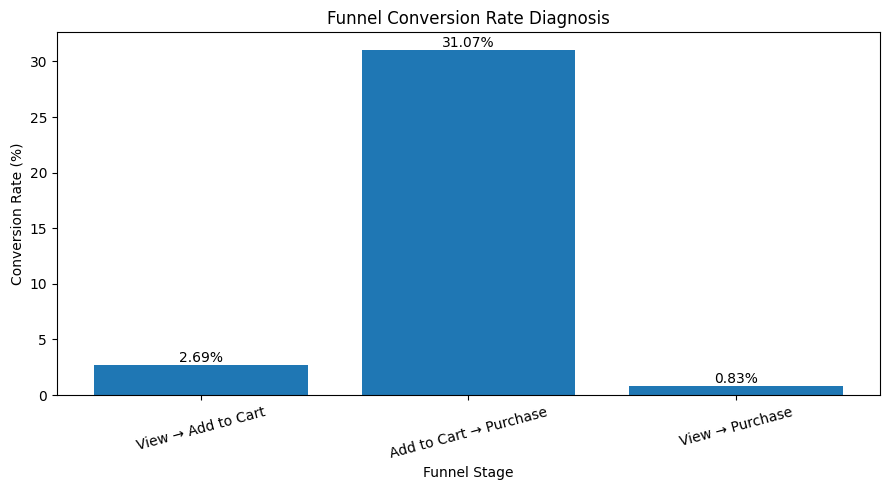

In [7]:
# ============================================================
# 6. Funnel Diagnosis Chart
# ============================================================

plot_df = problem_diagnosis.copy()

plt.figure(figsize=(9, 5))
plt.bar(plot_df["funnel_stage"], plot_df["conversion_rate_pct"])
plt.title("Funnel Conversion Rate Diagnosis")
plt.xlabel("Funnel Stage")
plt.ylabel("Conversion Rate (%)")

for i, v in enumerate(plot_df["conversion_rate_pct"]):
    plt.text(i, v, f"{v:.2f}%", ha="center", va="bottom", fontsize=10)

plt.xticks(rotation=15)
plt.tight_layout()

save_chart("05_funnel_conversion_diagnosis.png")
plt.show()

## 4. Opportunity Prioritization

Prioritize opportunities by traffic, current conversion, expected impact, feasibility, implementation complexity, and downstream risk.

In [8]:
# ============================================================
# 7. Opportunity Prioritization Framework
# ============================================================

opportunity_prioritization_framework = pd.DataFrame([
    {
        "priority": 1,
        "target_area": "High-traffic low-conversion categories/items",
        "reason": "Traffic already exists, but conversion is underperforming.",
        "recommended_action": "Run CTA, benefit-message, review-trust, and recommendation-module A/B tests.",
        "expected_impact": "High",
        "implementation_complexity": "Medium",
        "risk_level": "Medium",
    },
    {
        "priority": 2,
        "target_area": "Low-traffic high-conversion categories/items",
        "reason": "These areas convert well but are underexposed.",
        "recommended_action": "Increase exposure through recommendation slots, search ranking, or promotional modules.",
        "expected_impact": "Medium to High",
        "implementation_complexity": "Medium",
        "risk_level": "Low to Medium",
    },
    {
        "priority": 3,
        "target_area": "Star categories/items",
        "reason": "They already perform well and can be used as reference benchmarks.",
        "recommended_action": "Maintain exposure and analyze common UX/product traits.",
        "expected_impact": "Medium",
        "implementation_complexity": "Low",
        "risk_level": "Low",
    },
    {
        "priority": 4,
        "target_area": "Long-tail low-traffic low-conversion categories/items",
        "reason": "Low immediate impact and insufficient traffic for reliable testing.",
        "recommended_action": "Monitor periodically; do not prioritize for first experiment cycle.",
        "expected_impact": "Low",
        "implementation_complexity": "Low to Medium",
        "risk_level": "Low",
    },
])

display(opportunity_prioritization_framework)
save_table(opportunity_prioritization_framework, "05_opportunity_prioritization_framework.csv")

,priority,target_area,reason,recommended_action,expected_impact,implementation_complexity,risk_level
0,1,High-traffic low-conversion categories/items,"Traffic already exists, but conversion is unde...","Run CTA, benefit-message, review-trust, and re...",High,Medium,Medium
1,2,Low-traffic high-conversion categories/items,These areas convert well but are underexposed.,Increase exposure through recommendation slots...,Medium to High,Medium,Low to Medium
2,3,Star categories/items,They already perform well and can be used as r...,Maintain exposure and analyze common UX/produc...,Medium,Low,Low
3,4,Long-tail low-traffic low-conversion categorie...,Low immediate impact and insufficient traffic ...,Monitor periodically; do not prioritize for fi...,Low,Low to Medium,Low


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\05_opportunity_prioritization_framework.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/05_opportunity_prioritization_framework.csv')

## 5. Experiment Roadmap

Design targeted experiments rather than changing everything at once.

In [9]:
# ============================================================
# 8. A/B Test Roadmap
# ============================================================

abtest_roadmap = pd.DataFrame([
    {
        "experiment_order": 1,
        "experiment_name": "Product Detail CTA Optimization",
        "target": "High-traffic low-conversion product/category pages",
        "control": "Current CTA layout and copy",
        "treatment": "More visible add-to-cart CTA with benefit-oriented copy",
        "primary_metric": "View → Add to Cart conversion rate",
        "guardrail_metric": "View → Purchase conversion rate",
        "expected_effect": "Increase cart-entry conversion",
        "priority_reason": "Directly targets the largest funnel bottleneck.",
    },
    {
        "experiment_order": 2,
        "experiment_name": "Trust & Review Signal Enhancement",
        "target": "Products with high views but weak purchase conversion",
        "control": "Current product detail information layout",
        "treatment": "Enhanced review, rating, delivery, return, or benefit information near CTA",
        "primary_metric": "View → Add to Cart conversion rate",
        "guardrail_metric": "View → Purchase conversion rate",
        "expected_effect": "Reduce uncertainty before cart entry",
        "priority_reason": "Users may need stronger persuasion before adding products to cart.",
    },
    {
        "experiment_order": 3,
        "experiment_name": "Recommendation Exposure Expansion",
        "target": "Low-traffic high-conversion categories/items",
        "control": "Current recommendation exposure",
        "treatment": "Expanded exposure in recommendation modules or search result areas",
        "primary_metric": "View → Add to Cart conversion rate",
        "guardrail_metric": "View → Purchase conversion rate",
        "expected_effect": "Increase qualified traffic to high-converting items",
        "priority_reason": "These items already convert well but need more visibility.",
    },
    {
        "experiment_order": 4,
        "experiment_name": "Cart Incentive Messaging",
        "target": "Users who view multiple products without cart entry",
        "control": "No additional cart-entry incentive",
        "treatment": "Light incentive or benefit reminder before exit or after repeated views",
        "primary_metric": "View → Add to Cart conversion rate",
        "guardrail_metric": "View → Purchase conversion rate",
        "expected_effect": "Encourage undecided users to move into cart",
        "priority_reason": "Targets users showing browsing intent but no cart action.",
    },
])

display(abtest_roadmap)
save_table(abtest_roadmap, "05_abtest_roadmap.csv")

,experiment_order,experiment_name,target,control,treatment,primary_metric,guardrail_metric,expected_effect,priority_reason
0,1,Product Detail CTA Optimization,High-traffic low-conversion product/category p...,Current CTA layout and copy,More visible add-to-cart CTA with benefit-orie...,View → Add to Cart conversion rate,View → Purchase conversion rate,Increase cart-entry conversion,Directly targets the largest funnel bottleneck.
1,2,Trust & Review Signal Enhancement,Products with high views but weak purchase con...,Current product detail information layout,"Enhanced review, rating, delivery, return, or ...",View → Add to Cart conversion rate,View → Purchase conversion rate,Reduce uncertainty before cart entry,Users may need stronger persuasion before addi...
2,3,Recommendation Exposure Expansion,Low-traffic high-conversion categories/items,Current recommendation exposure,Expanded exposure in recommendation modules or...,View → Add to Cart conversion rate,View → Purchase conversion rate,Increase qualified traffic to high-converting ...,These items already convert well but need more...
3,4,Cart Incentive Messaging,Users who view multiple products without cart ...,No additional cart-entry incentive,Light incentive or benefit reminder before exi...,View → Add to Cart conversion rate,View → Purchase conversion rate,Encourage undecided users to move into cart,Targets users showing browsing intent but no c...


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\05_abtest_roadmap.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/05_abtest_roadmap.csv')

## 6. Business Impact Summary

Summarize expected incremental add-to-cart users by uplift scenario per 100,000 view users.

In [10]:
# ============================================================
# 9. Business Impact Summary
# ============================================================

impact_100k = business_impact_scenarios.loc[
    business_impact_scenarios["target_exposures"] == 100000
].copy()

impact_100k = impact_100k[
    [
        "relative_uplift_pct",
        "baseline_rate",
        "treatment_rate",
        "absolute_lift",
        "expected_baseline_conversions",
        "expected_treatment_conversions",
        "expected_incremental_conversions",
    ]
].sort_values("relative_uplift_pct")

impact_100k["baseline_rate_pct"] = impact_100k["baseline_rate"] * 100
impact_100k["treatment_rate_pct"] = impact_100k["treatment_rate"] * 100
impact_100k["absolute_lift_pct_point"] = impact_100k["absolute_lift"] * 100

display(impact_100k)
save_table(impact_100k, "05_business_impact_summary_per_100k.csv")

,relative_uplift_pct,baseline_rate,treatment_rate,absolute_lift,expected_baseline_conversions,expected_treatment_conversions,expected_incremental_conversions,baseline_rate_pct,treatment_rate_pct,absolute_lift_pct_point
2,5.000000,0.026864,0.028207,0.001343,"2,686.409639","2,820.730121",134.320482,2.686410,2.820730,0.134320
8,10.000000,0.026864,0.029551,0.002686,"2,686.409639","2,955.050603",268.640964,2.686410,2.955051,0.268641
14,15.000000,0.026864,0.030894,0.004030,"2,686.409639","3,089.371084",402.961446,2.686410,3.089371,0.402961
20,20.000000,0.026864,0.032237,0.005373,"2,686.409639","3,223.691566",537.281928,2.686410,3.223692,0.537282
26,30.000000,0.026864,0.034923,0.008059,"2,686.409639","3,492.332530",805.922892,2.686410,3.492333,0.805923


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\05_business_impact_summary_per_100k.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/05_business_impact_summary_per_100k.csv')

saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\charts\05_business_impact_per_100k.png


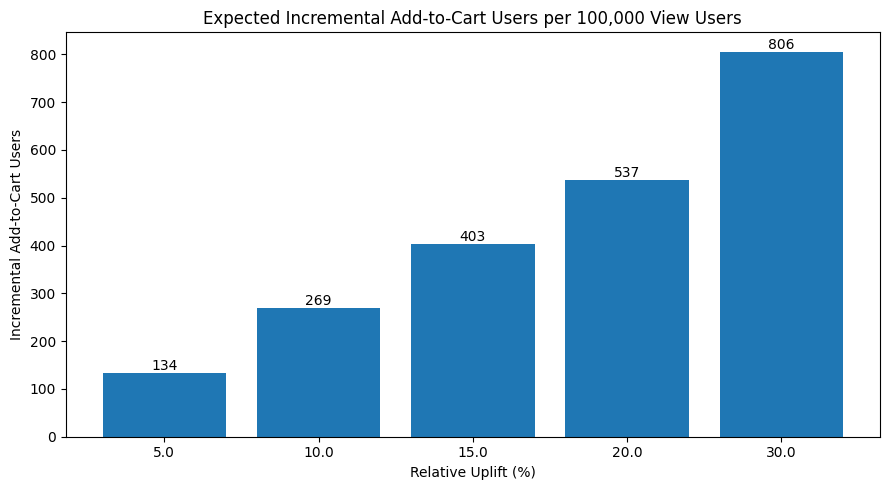

In [11]:
# ============================================================
# 10. Business Impact Chart
# ============================================================

plt.figure(figsize=(9, 5))
plt.bar(
    impact_100k["relative_uplift_pct"].astype(str),
    impact_100k["expected_incremental_conversions"],
)
plt.title("Expected Incremental Add-to-Cart Users per 100,000 View Users")
plt.xlabel("Relative Uplift (%)")
plt.ylabel("Incremental Add-to-Cart Users")

for i, v in enumerate(impact_100k["expected_incremental_conversions"]):
    plt.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
save_chart("05_business_impact_per_100k.png")
plt.show()

## 7. Final Recommendation

In [12]:
# ============================================================
# 11. Final Recommendation Table
# ============================================================

final_recommendation = pd.DataFrame([
    {
        "recommendation_id": "R1",
        "recommendation": "Use View → Add to Cart as the primary experiment metric.",
        "evidence": f"The baseline View → Add to Cart conversion rate is {view_to_cart * 100:.2f}%, indicating the largest bottleneck before cart entry.",
        "expected_value": "Directly targets the earliest major conversion loss.",
        "priority": "High",
    },
    {
        "recommendation_id": "R2",
        "recommendation": "Prioritize high-traffic low-conversion products and categories.",
        "evidence": "Item/category opportunity analysis identified segments with high visibility but weak conversion.",
        "expected_value": "Improves conversion without requiring additional acquisition traffic.",
        "priority": "High",
    },
    {
        "recommendation_id": "R3",
        "recommendation": "Run CTA and benefit-message A/B tests on product detail pages.",
        "evidence": "The main friction occurs between product view and cart entry.",
        "expected_value": "Can increase qualified cart entries and downstream purchase opportunities.",
        "priority": "High",
    },
    {
        "recommendation_id": "R4",
        "recommendation": "Use View → Purchase as a guardrail metric.",
        "evidence": "Cart conversion alone can be misleading if it does not translate into purchase conversion.",
        "expected_value": "Prevents shallow engagement optimization.",
        "priority": "High",
    },
    {
        "recommendation_id": "R5",
        "recommendation": "Expand exposure for low-traffic high-conversion products/categories.",
        "evidence": "Some products/categories show strong conversion despite limited traffic.",
        "expected_value": "Can generate additional conversions by reallocating recommendation or search exposure.",
        "priority": "Medium",
    },
    {
        "recommendation_id": "R6",
        "recommendation": "Plan experiments around realistic uplift and sample-size requirements.",
        "evidence": f"A +10% relative uplift requires about {int(uplift_10['required_sample_size_per_group']):,} users per group.",
        "expected_value": "Improves experiment reliability and prevents underpowered tests.",
        "priority": "High",
    },
])

display(final_recommendation)
save_table(final_recommendation, "05_final_recommendation.csv")

,recommendation_id,recommendation,evidence,expected_value,priority
0,R1,Use View → Add to Cart as the primary experime...,The baseline View → Add to Cart conversion rat...,Directly targets the earliest major conversion...,High
1,R2,Prioritize high-traffic low-conversion product...,Item/category opportunity analysis identified ...,Improves conversion without requiring addition...,High
2,R3,Run CTA and benefit-message A/B tests on produ...,The main friction occurs between product view ...,Can increase qualified cart entries and downst...,High
3,R4,Use View → Purchase as a guardrail metric.,Cart conversion alone can be misleading if it ...,Prevents shallow engagement optimization.,High
4,R5,Expand exposure for low-traffic high-conversio...,Some products/categories show strong conversio...,Can generate additional conversions by realloc...,Medium
5,R6,Plan experiments around realistic uplift and s...,"A +10% relative uplift requires about 59,592 u...",Improves experiment reliability and prevents u...,High


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\05_final_recommendation.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/05_final_recommendation.csv')

## 8. Decision Rule

Deployment should consider statistical significance, guardrail metrics, practical impact, and implementation risk.

In [13]:
# ============================================================
# 12. Experiment Decision Rule
# ============================================================

experiment_decision_rule = pd.DataFrame([
    {
        "condition": "Primary metric improves significantly",
        "metric": "View → Add to Cart",
        "required_result": "Treatment > Control and p-value < 0.05",
        "decision_meaning": "Treatment successfully improves cart-entry conversion.",
    },
    {
        "condition": "Guardrail metric does not deteriorate",
        "metric": "View → Purchase",
        "required_result": "No meaningful decline in purchase conversion",
        "decision_meaning": "Treatment does not create low-quality cart behavior.",
    },
    {
        "condition": "Business impact is meaningful",
        "metric": "Incremental add-to-cart or purchase users",
        "required_result": "Incremental conversions justify implementation cost",
        "decision_meaning": "Statistical significance translates into practical value.",
    },
    {
        "condition": "Sample size is sufficient",
        "metric": "Users per group",
        "required_result": "Meets required sample size from power analysis",
        "decision_meaning": "Experiment result is reliable enough for decision-making.",
    },
    {
        "condition": "Implementation risk is acceptable",
        "metric": "UX, engineering, operational risk",
        "required_result": "No critical downside identified",
        "decision_meaning": "Treatment can be safely rolled out.",
    },
])

display(experiment_decision_rule)
save_table(experiment_decision_rule, "05_experiment_decision_rule.csv")

,condition,metric,required_result,decision_meaning
0,Primary metric improves significantly,View → Add to Cart,Treatment > Control and p-value < 0.05,Treatment successfully improves cart-entry con...
1,Guardrail metric does not deteriorate,View → Purchase,No meaningful decline in purchase conversion,Treatment does not create low-quality cart beh...
2,Business impact is meaningful,Incremental add-to-cart or purchase users,Incremental conversions justify implementation...,Statistical significance translates into pract...
3,Sample size is sufficient,Users per group,Meets required sample size from power analysis,Experiment result is reliable enough for decis...
4,Implementation risk is acceptable,"UX, engineering, operational risk",No critical downside identified,Treatment can be safely rolled out.


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\05_experiment_decision_rule.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/05_experiment_decision_rule.csv')

## 9. Streamlit Dashboard Storyline

In [14]:
# ============================================================
# 13. Streamlit Storyline
# ============================================================

streamlit_storyline = pd.DataFrame([
    {
        "page": "Executive Summary",
        "main_question": "What is the key business problem?",
        "main_content": "Overall funnel bottleneck, primary metric, expected impact.",
        "user_takeaway": "The biggest opportunity is before cart entry.",
    },
    {
        "page": "Funnel Analysis",
        "main_question": "Where do users drop off?",
        "main_content": "View → Cart → Purchase funnel and conversion rates.",
        "user_takeaway": "View → Add to Cart is the primary bottleneck.",
    },
    {
        "page": "Item & Category Insights",
        "main_question": "Which products/categories should be prioritized?",
        "main_content": "Top items, category performance, opportunity matrix.",
        "user_takeaway": "High-traffic low-conversion areas are the first optimization targets.",
    },
    {
        "page": "A/B Test Simulation",
        "main_question": "What uplift is needed and how many users are required?",
        "main_content": "Sample size scenarios, z-test, Monte Carlo simulation, business impact.",
        "user_takeaway": "Experiment planning must consider statistical power and expected impact.",
    },
    {
        "page": "Business Action Plan",
        "main_question": "What should the business do next?",
        "main_content": "Experiment roadmap, final recommendations, decision rule.",
        "user_takeaway": "Run targeted experiments before broad platform changes.",
    },
])

display(streamlit_storyline)
save_table(streamlit_storyline, "05_streamlit_storyline.csv")

,page,main_question,main_content,user_takeaway
0,Executive Summary,What is the key business problem?,"Overall funnel bottleneck, primary metric, exp...",The biggest opportunity is before cart entry.
1,Funnel Analysis,Where do users drop off?,View → Cart → Purchase funnel and conversion r...,View → Add to Cart is the primary bottleneck.
2,Item & Category Insights,Which products/categories should be prioritized?,"Top items, category performance, opportunity m...",High-traffic low-conversion areas are the firs...
3,A/B Test Simulation,What uplift is needed and how many users are r...,"Sample size scenarios, z-test, Monte Carlo sim...",Experiment planning must consider statistical ...
4,Business Action Plan,What should the business do next?,"Experiment roadmap, final recommendations, dec...",Run targeted experiments before broad platform...


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\05_streamlit_storyline.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/05_streamlit_storyline.csv')

## 10. README / WikiDocs Summary

In [15]:
# ============================================================
# 14. README and WikiDocs Summary
# ============================================================

readme_wikidocs_summary = pd.DataFrame([
    {
        "section": "Project summary",
        "text": "This project analyzes large-scale e-commerce behavioral logs to diagnose funnel bottlenecks and design A/B Test strategies for improving conversion.",
    },
    {
        "section": "Key finding",
        "text": f"The largest bottleneck occurs before cart entry, with a View → Add to Cart conversion rate of {view_to_cart * 100:.2f}%.",
    },
    {
        "section": "Analytical contribution",
        "text": "The project connects raw data audit, funnel analytics, item/category opportunity analysis, A/B Test design, sample-size estimation, and business recommendation.",
    },
    {
        "section": "Business contribution",
        "text": "Rather than recommending broad platform changes, the analysis prioritizes high-traffic low-conversion products and categories as the first experiment targets.",
    },
    {
        "section": "Experiment design",
        "text": "The recommended primary metric is View → Add to Cart conversion rate, while View → Purchase is used as a downstream guardrail metric.",
    },
])

display(readme_wikidocs_summary)
save_table(readme_wikidocs_summary, "05_readme_wikidocs_summary.csv")

,section,text
0,Project summary,This project analyzes large-scale e-commerce b...
1,Key finding,The largest bottleneck occurs before cart entr...
2,Analytical contribution,"The project connects raw data audit, funnel an..."
3,Business contribution,Rather than recommending broad platform change...
4,Experiment design,The recommended primary metric is View → Add t...


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\05_readme_wikidocs_summary.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/05_readme_wikidocs_summary.csv')

In [16]:
# ============================================================
# 15. Save Streamlit-Ready Business Tables
# ============================================================

streamlit_tables = {
    "business_executive_summary.parquet": executive_summary,
    "business_problem_diagnosis.parquet": problem_diagnosis,
    "business_opportunity_prioritization.parquet": opportunity_prioritization_framework,
    "business_abtest_roadmap.parquet": abtest_roadmap,
    "business_impact_summary_per_100k.parquet": impact_100k,
    "business_final_recommendation.parquet": final_recommendation,
    "business_experiment_decision_rule.parquet": experiment_decision_rule,
    "business_streamlit_storyline.parquet": streamlit_storyline,
    "business_readme_wikidocs_summary.parquet": readme_wikidocs_summary,
}

for filename, df in streamlit_tables.items():
    save_path = PROCESSED_DIR / filename
    try:
        df.to_parquet(save_path, index=False)
        print(f"saved: {save_path}")
    except Exception as e:
        print(f"parquet save failed for {filename}: {e}")

print("05_business_recommendation completed.")
print("Next step: src/utils.py refactoring or Streamlit dashboard.")

parquet save failed for business_executive_summary.parquet: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.
parquet save failed for business_problem_diagnosis.parquet: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or co